# Behavioural Risk Model — Delinquency Prediction (PD)
*Module B · Notebook 2 of 4 · AI Risk Decisioning System*

---

## Business Context

This notebook builds the **Probability of Delinquency model** for Module B — the behavioural complement to Module A's application-time PD model.

The key difference between the two modules:

| Dimension | Module A (Application Risk) | Module B (Behavioural Risk) |
|-----------|-----------------------------|-----------------------------|
| Signal type | Point-in-time snapshot | Observed behaviour over 2 years |
| Data source | Application form + bureau | Credit bureau payment history |
| Question answered | "What does this borrower look like?" | "How has this borrower actually behaved?" |
| Primary predictor | External bureau scores (EXT_SOURCE) | Delinquency counts, revolving utilisation |
| Use case | Origination decision | Ongoing monitoring + re-decisioning |

Together, these two signals form the first two inputs to the Decision Engine's composite risk score.

## Objectives

1. Train a **Logistic Regression** model — interpretable baseline for regulatory review
2. Train an **XGBoost** model — performance champion
3. Evaluate using **AUC, KS Statistic, Gini** — consistent with Module A framework
4. Assign a **Behavioural Risk Band** (1–5) from delinquency probability
5. Compute a **Behavioural Risk Score** (0–100) for the Decision Engine
6. Save models and scored output for downstream notebooks

## Inputs
- `../01_data/processed/X_train_b.csv`
- `../01_data/processed/X_test_b.csv`
- `../01_data/processed/y_train_b.csv`
- `../01_data/processed/y_test_b.csv`

## Outputs
- `../01_data/processed/scored_test_b.csv` — test set with delinquency probability + behavioural risk bands
- `../03_models/lr_behavioural.pkl` — Logistic Regression model + scaler
- `../03_models/xgb_behavioural.pkl` — XGBoost model


In [7]:
# ── Setup ─────────────────────────────────────────────────────────────────────
!pip install xgboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import os
import pickle

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

os.makedirs("../03_models", exist_ok=True)

print("Libraries loaded.")
print("Module B — Delinquency Model initialised.")


Defaulting to user installation because normal site-packages is not writeable
  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Libraries loaded.
Module B — Delinquency Model initialised.


---
## 1. Load Preprocessed Data

In [8]:
X_train = pd.read_csv("../01_data/processed/X_train_b.csv")
X_test  = pd.read_csv("../01_data/processed/X_test_b.csv")
y_train = pd.read_csv("../01_data/processed/y_train_b.csv").squeeze()
y_test  = pd.read_csv("../01_data/processed/y_test_b.csv").squeeze()

print(f"Training set : {X_train.shape[0]:,} rows | {X_train.shape[1]} features")
print(f"Test set     : {X_test.shape[0]:,} rows")
print(f"Delinquency rate (train) : {y_train.mean():.4f}")
print(f"Delinquency rate (test)  : {y_test.mean():.4f}")
print(f"\nFeatures: {list(X_train.columns)}")


Training set : 119,784 rows | 18 features
Test set     : 29,946 rows
Delinquency rate (train) : 0.0660
Delinquency rate (test)  : 0.0660

Features: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'INCOME_MISSING', 'DELINQUENCY_SCORE', 'WORST_DELINQUENCY', 'HAS_90DAY_LATE', 'UTILIZATION_RISK_BAND', 'DEBT_TO_INCOME', 'INCOME_PER_DEPENDENT', 'CREDIT_LINES_RISK']


---
## 2. Class Imbalance — Handling Strategy

At 6.68% delinquency rate, the minority class is significantly underrepresented.

**Strategy:**
- **Logistic Regression:** `class_weight='balanced'` — automatically upweights minority class by the imbalance ratio
- **XGBoost:** `scale_pos_weight = n_negative / n_positive` — equivalent mechanism, native to XGBoost

Both approaches preserve all training data (no oversampling/undersampling) while correcting the learning signal. This is the regulatory standard — SMOTE and resampling techniques are harder to explain to model validators.

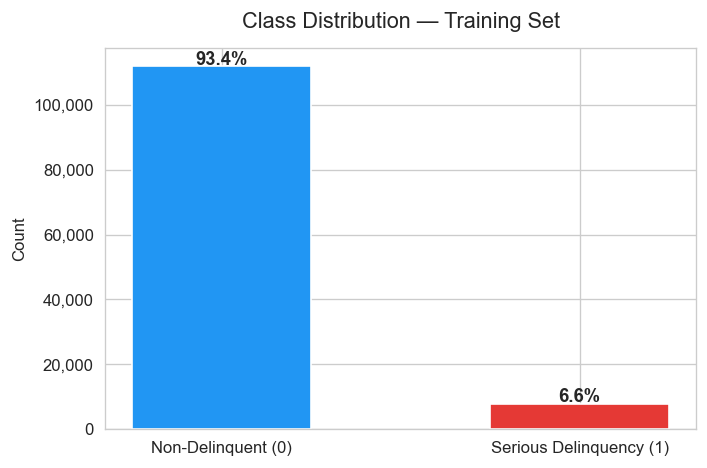

Imbalance ratio      : 14.2:1 (non-delinquent to delinquent)
scale_pos_weight     : 14.16  (used in XGBoost)
class_weight='balanced' equivalent ratio for LR: 14.16


In [9]:
n_pos = y_train.sum()
n_neg = (y_train == 0).sum()
spw   = n_neg / n_pos

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Non-Delinquent (0)", "Serious Delinquency (1)"],
              [n_neg, n_pos], color=["#2196F3", "#E53935"],
              width=0.5, edgecolor="white")
for bar, pct in zip(bars, [n_neg/(n_neg+n_pos)*100, n_pos/(n_neg+n_pos)*100]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f"{pct:.1f}%", ha="center", fontsize=11, fontweight="bold")
ax.set_title("Class Distribution — Training Set", fontsize=13, pad=12)
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

print(f"Imbalance ratio      : {spw:.1f}:1 (non-delinquent to delinquent)")
print(f"scale_pos_weight     : {spw:.2f}  (used in XGBoost)")
print(f"class_weight='balanced' equivalent ratio for LR: {spw:.2f}")


---
## 3. Model 1 — Logistic Regression (Regulatory Baseline)

**Why Logistic Regression first?**

In BFSI model governance, the sequence matters. The interpretable model is trained first because:
1. Its coefficients serve as a **sanity check** — are the signs in the expected direction?
2. It is the **challenger model** that a model validator will use to test whether the XGBoost complexity is justified
3. If the performance gap is small (< 2–3 AUC points), many risk committees prefer LR for the explainability benefit

A negative coefficient on `age` (older borrowers default less) and positive coefficients on delinquency counts are the expected direction. We verify this below.

In [10]:
# Scale features — critical for LR convergence
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
    solver="lbfgs",
    C=1.0
)
lr_model.fit(X_train_scaled, y_train)

lr_pd_train = lr_model.predict_proba(X_train_scaled)[:, 1]
lr_pd_test  = lr_model.predict_proba(X_test_scaled)[:, 1]

lr_auc = roc_auc_score(y_test, lr_pd_test)
print(f"Logistic Regression — Test AUC: {lr_auc:.4f}")

# ── Coefficient direction check ────────────────────────────────────────────────
coef_df = pd.DataFrame({
    "Feature"    : X_train.columns,
    "Coefficient": lr_model.coef_[0]
}).sort_values("Coefficient", ascending=False)

print("\nCOEFFICIENT DIRECTION AUDIT")
print("=" * 60)
print("Expected direction: delinquency features (+), age (-), income (-)")
print("─" * 60)
for _, row in coef_df.iterrows():
    direction = "↑ (increases risk)" if row["Coefficient"] > 0 else "↓ (reduces risk)"
    print(f"  {row['Feature']:<45} {row['Coefficient']:+.4f}  {direction}")

# ── Flag any counter-intuitive coefficients ────────────────────────────────────
print("\n✓ Sanity check: all delinquency features should have positive coefficients")
delinq_feats = ["NumberOfTime30-59DaysPastDueNotWorse", "NumberOfTimes90DaysLate",
                "NumberOfTime60-89DaysPastDueNotWorse", "DELINQUENCY_SCORE", "HAS_90DAY_LATE"]
for feat in delinq_feats:
    if feat in X_train.columns:
        coef = coef_df.loc[coef_df["Feature"]==feat, "Coefficient"].values[0]
        status = "✓" if coef > 0 else "✗ UNEXPECTED"
        print(f"  {feat}: {coef:+.4f}  {status}")


Logistic Regression — Test AUC: 0.8518

COEFFICIENT DIRECTION AUDIT
Expected direction: delinquency features (+), age (-), income (-)
────────────────────────────────────────────────────────────
  RevolvingUtilizationOfUnsecuredLines          +0.6643  ↑ (increases risk)
  WORST_DELINQUENCY                             +0.6058  ↑ (increases risk)
  NumberOfOpenCreditLinesAndLoans               +0.2385  ↑ (increases risk)
  NumberRealEstateLoansOrLines                  +0.1534  ↑ (increases risk)
  NumberOfTime30-59DaysPastDueNotWorse          +0.1230  ↑ (increases risk)
  DELINQUENCY_SCORE                             +0.1216  ↑ (increases risk)
  DEBT_TO_INCOME                                +0.0981  ↑ (increases risk)
  CREDIT_LINES_RISK                             +0.0647  ↑ (increases risk)
  NumberOfTimes90DaysLate                       +0.0629  ↑ (increases risk)
  NumberOfTime60-89DaysPastDueNotWorse          +0.0543  ↑ (increases risk)
  NumberOfDependents                         

---
## 4. Model 2 — XGBoost (Performance Champion)

XGBoost is trained with the same hyperparameter philosophy as Module A:
- `n_estimators=300`, `max_depth=5` — sufficient capacity without overfitting
- `scale_pos_weight` — handles class imbalance natively
- `subsample=0.8, colsample_bytree=0.8` — regularisation through stochastic sampling

In [11]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    eval_metric="auc",
    random_state=42,
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_pd_train = xgb_model.predict_proba(X_train)[:, 1]
xgb_pd_test  = xgb_model.predict_proba(X_test)[:, 1]

xgb_auc = roc_auc_score(y_test, xgb_pd_test)
print(f"XGBoost — Test AUC: {xgb_auc:.4f}")


XGBoost — Test AUC: 0.8571


---
## 5. Model Evaluation — AUC, KS, Gini

Same evaluation framework as Module A — enabling direct cross-module comparison.

| Metric | Threshold (Good Model) | Module A XGBoost | Module B XGBoost |
|--------|------------------------|------------------|------------------|
| AUC | > 0.70 | *see NB02* | *see output* |
| KS | > 0.30 | *see NB02* | *see output* |
| Gini | > 0.40 | *see NB02* | *see output* |

In [12]:
def ks_statistic(y_true, y_prob):
    """KS statistic — maximum separation between default/non-default CDFs."""
    df_ks = pd.DataFrame({"y_true": y_true, "y_prob": y_prob})
    df_ks = df_ks.sort_values("y_prob", ascending=False).reset_index(drop=True)
    n_pos = df_ks["y_true"].sum()
    n_neg = len(df_ks) - n_pos
    df_ks["cum_pos"] = df_ks["y_true"].cumsum() / n_pos
    df_ks["cum_neg"] = (1 - df_ks["y_true"]).cumsum() / n_neg
    df_ks["ks"]      = abs(df_ks["cum_pos"] - df_ks["cum_neg"])
    return df_ks["ks"].max()

lr_ks  = ks_statistic(y_test.values, lr_pd_test)
xgb_ks = ks_statistic(y_test.values, xgb_pd_test)

metrics = pd.DataFrame({
    "Model" : ["Logistic Regression", "XGBoost"],
    "AUC"   : [round(lr_auc, 4),        round(xgb_auc, 4)],
    "KS"    : [round(lr_ks, 4),         round(xgb_ks, 4)],
    "Gini"  : [round(2*lr_auc-1, 4),    round(2*xgb_auc-1, 4)]
})

print("=" * 55)
print("MODEL PERFORMANCE — MODULE B (BEHAVIOURAL RISK)")
print("=" * 55)
print(metrics.to_string(index=False))
print("=" * 55)
print("\nBenchmark: AUC > 0.70 | KS > 0.30 | Gini > 0.40")
print("\nChampion model: XGBoost (higher AUC)")
print("Challenger model: Logistic Regression (regulatory baseline)")


MODEL PERFORMANCE — MODULE B (BEHAVIOURAL RISK)
              Model    AUC     KS   Gini
Logistic Regression 0.8518 0.5474 0.7036
            XGBoost 0.8571 0.5630 0.7142

Benchmark: AUC > 0.70 | KS > 0.30 | Gini > 0.40

Champion model: XGBoost (higher AUC)
Challenger model: Logistic Regression (regulatory baseline)


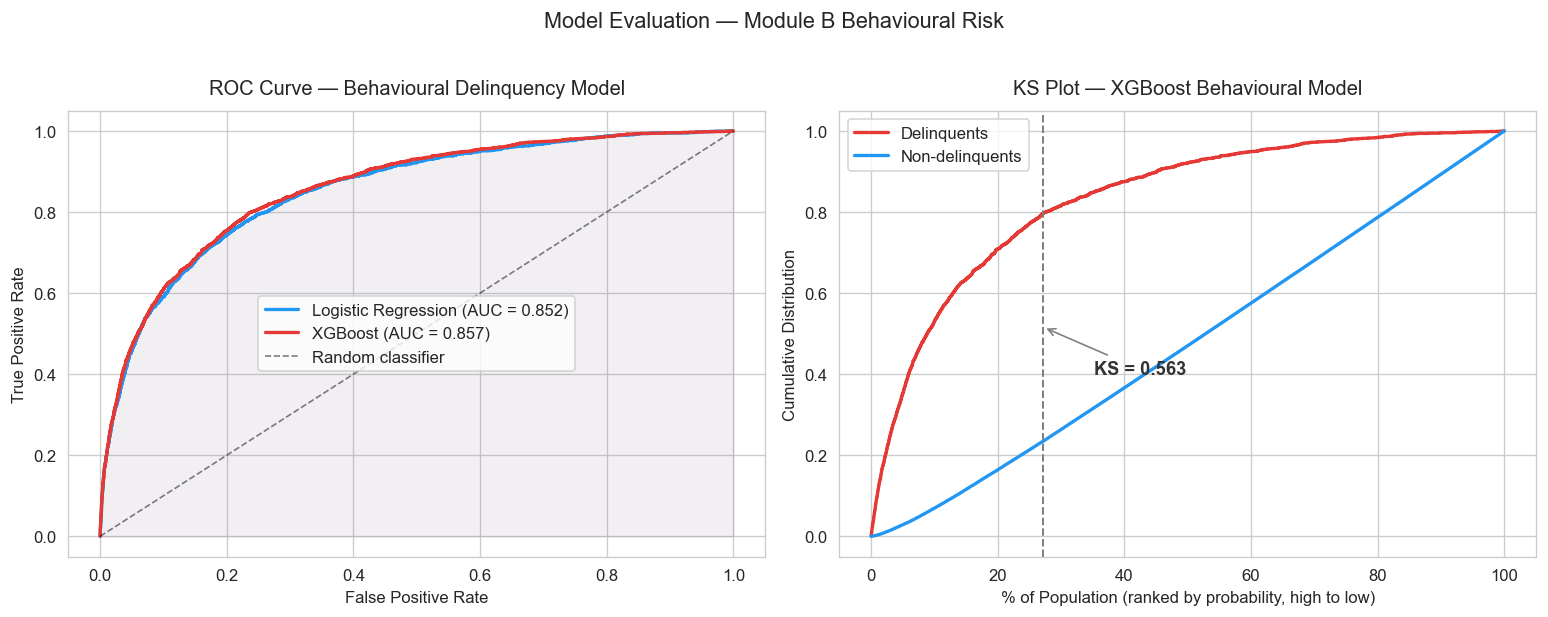

In [13]:
# ROC Curves
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, lr_pd_test)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_pd_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
axes[0].plot(fpr_lr,  tpr_lr,  color="#2196F3", lw=2,
             label=f"Logistic Regression (AUC = {lr_auc:.3f})")
axes[0].plot(fpr_xgb, tpr_xgb, color="#E53935", lw=2,
             label=f"XGBoost (AUC = {xgb_auc:.3f})")
axes[0].plot([0,1],[0,1], "k--", lw=1, alpha=0.5, label="Random classifier")
axes[0].fill_between(fpr_lr,  tpr_lr,  alpha=0.05, color="#2196F3")
axes[0].fill_between(fpr_xgb, tpr_xgb, alpha=0.05, color="#E53935")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — Behavioural Delinquency Model", fontsize=12, pad=10)
axes[0].legend(fontsize=10)

# KS Plot for XGBoost
df_ks = pd.DataFrame({"y_true": y_test.values, "y_prob": xgb_pd_test})
df_ks = df_ks.sort_values("y_prob", ascending=False).reset_index(drop=True)
n_pos = df_ks["y_true"].sum()
n_neg = len(df_ks) - n_pos
df_ks["cum_pos"] = df_ks["y_true"].cumsum() / n_pos
df_ks["cum_neg"] = (1 - df_ks["y_true"]).cumsum() / n_neg
ks_val = abs(df_ks["cum_pos"] - df_ks["cum_neg"]).max()
ks_idx = abs(df_ks["cum_pos"] - df_ks["cum_neg"]).idxmax()
pct_pop = np.arange(len(df_ks)) / len(df_ks) * 100

axes[1].plot(pct_pop, df_ks["cum_pos"], color="#E53935", lw=2, label="Delinquents")
axes[1].plot(pct_pop, df_ks["cum_neg"], color="#2196F3", lw=2, label="Non-delinquents")
axes[1].axvline(pct_pop[ks_idx], color="gray", linestyle="--", lw=1.2)
axes[1].annotate(f"KS = {ks_val:.3f}",
    xy=(pct_pop[ks_idx], (df_ks["cum_pos"].iloc[ks_idx]+df_ks["cum_neg"].iloc[ks_idx])/2),
    fontsize=11, fontweight="bold", color="#333",
    xytext=(pct_pop[ks_idx]+8, 0.4),
    arrowprops=dict(arrowstyle="->", color="gray"))
axes[1].set_xlabel("% of Population (ranked by probability, high to low)")
axes[1].set_ylabel("Cumulative Distribution")
axes[1].set_title("KS Plot — XGBoost Behavioural Model", fontsize=12, pad=10)
axes[1].legend(fontsize=10)

plt.suptitle("Model Evaluation — Module B Behavioural Risk", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---
## 6. Feature Importance — Top Behavioural Risk Drivers

The conceptual soundness check for Module B: do the features that drive the model align with established behavioural credit risk knowledge?

**Expected findings:**
- `HAS_90DAY_LATE` or `NumberOfTimes90DaysLate` should dominate — most severe delinquency event
- `DELINQUENCY_SCORE` — cumulative severity
- `RevolvingUtilizationOfUnsecuredLines` — financial strain signal
- `age` — negative direction (older = lower risk)

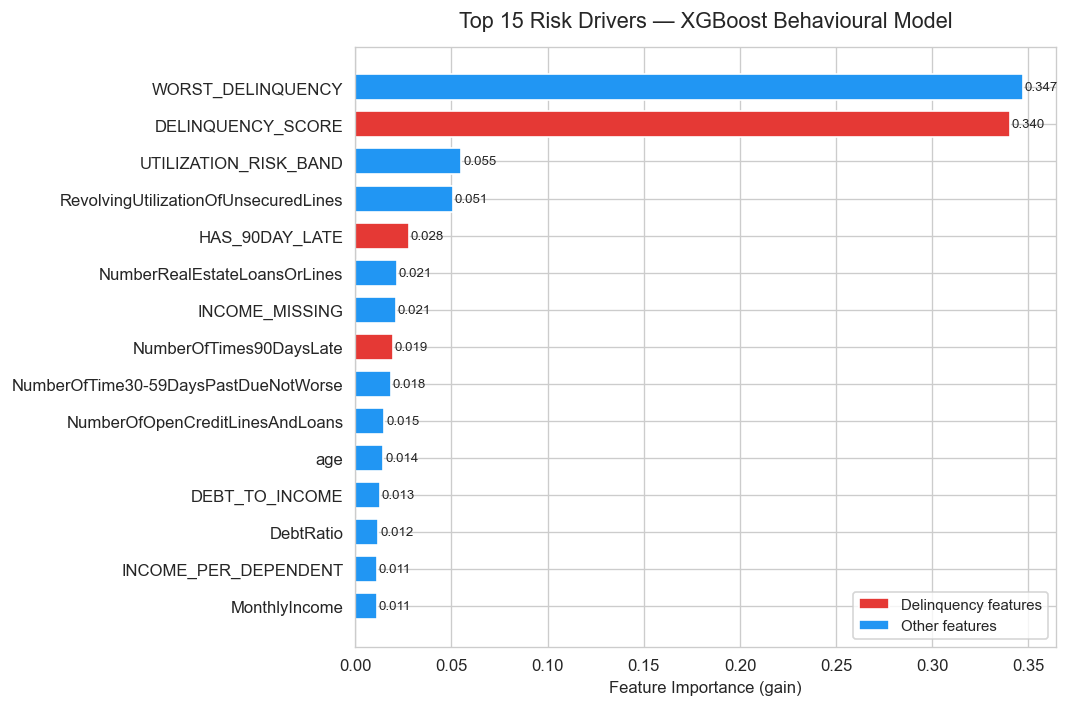

Top 5 behavioural risk drivers:
  WORST_DELINQUENCY: 0.3470
  DELINQUENCY_SCORE: 0.3401
  UTILIZATION_RISK_BAND: 0.0550
  RevolvingUtilizationOfUnsecuredLines: 0.0507
  HAS_90DAY_LATE: 0.0277


In [14]:
importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
top_feats   = importances.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors_imp = ["#E53935" if f in ["HAS_90DAY_LATE","NumberOfTimes90DaysLate","DELINQUENCY_SCORE"]
              else "#2196F3" for f in top_feats.index]
bars = ax.barh(top_feats.index, top_feats.values, color=colors_imp, edgecolor="white", height=0.7)
for bar, val in zip(bars, top_feats.values):
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=8)
ax.set_xlabel("Feature Importance (gain)")
ax.set_title("Top 15 Risk Drivers — XGBoost Behavioural Model", fontsize=13, pad=12)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#E53935", label="Delinquency features"),
    Patch(facecolor="#2196F3", label="Other features")
]
ax.legend(handles=legend_elements, fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()

print("Top 5 behavioural risk drivers:")
for feat, imp in importances.nlargest(5).items():
    print(f"  {feat}: {imp:.4f}")


---
## 7. Behavioural Risk Banding

Raw probabilities (e.g. 0.043) are not actionable. We assign each borrower to a **Behavioural Risk Band** (1–5) that the Decision Engine can combine with Module A's risk band.

The thresholds are set relative to the dataset's delinquency rate (6.68%) rather than fixed values — this ensures the band distribution is meaningful for this population.

| Band | Probability Threshold | Risk Level | Decision Engine Interpretation |
|------|----------------------|------------|-------------------------------|
| 1 | < 3% | Very Low | Reinforces Module A approval |
| 2 | 3–7% | Low | Consistent with population average |
| 3 | 7–15% | Medium | Warrants attention if Module A is also medium |
| 4 | 15–30% | High | Override possible even if Module A is low-moderate |
| 5 | > 30% | Very High | Strong decline signal regardless of Module A |

BEHAVIOURAL RISK BAND DISTRIBUTION
 Band Prob Range Risk Level  Count % Portfolio Actual Delinq
    1       < 3%   Very Low    905        3.0%          0.4%
    2       3–7%        Low   4111       13.7%          0.4%
    3      7–15%     Medium   6991       23.3%          1.2%
    4     15–30%       High   6432       21.5%          2.5%
    5      > 30%  Very High  11507       38.4%         14.9%


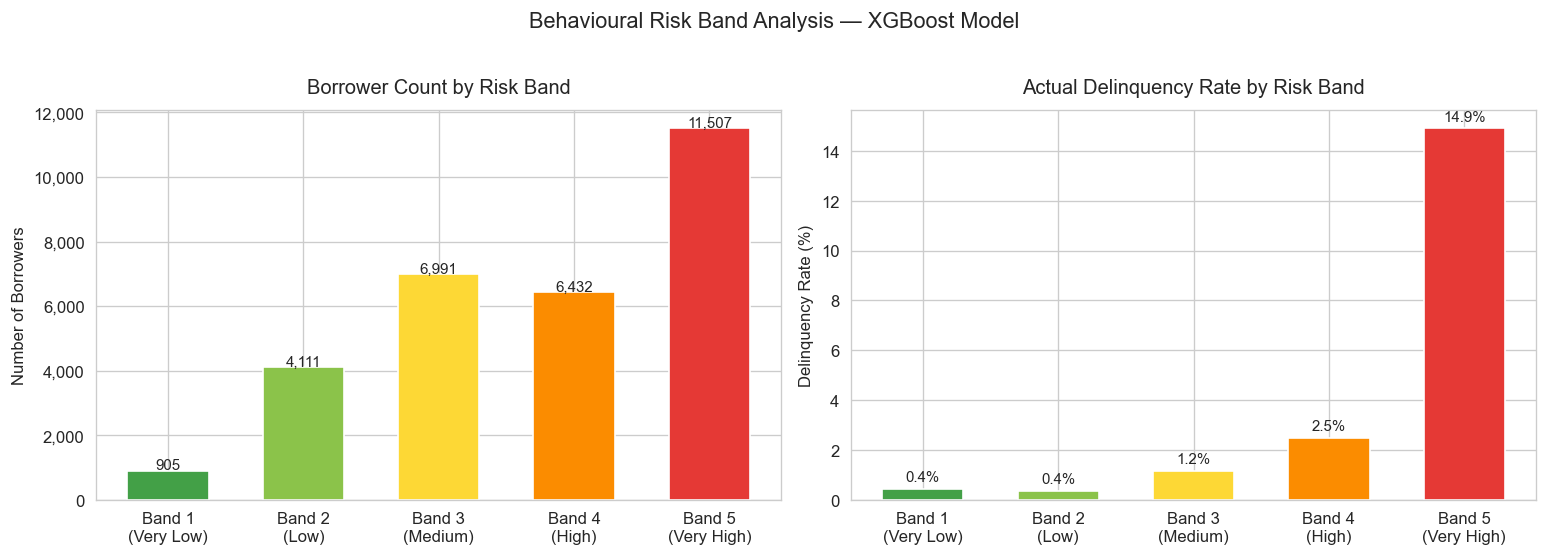

In [15]:
def assign_behavioural_band(p):
    """Map delinquency probability to risk band 1–5."""
    if p < 0.03:  return 1
    if p < 0.07:  return 2
    if p < 0.15:  return 3
    if p < 0.30:  return 4
    return 5

risk_bands_b = pd.Series(xgb_pd_test).apply(assign_behavioural_band)

band_summary = pd.DataFrame({
    "Band"           : [1, 2, 3, 4, 5],
    "Prob Range"     : ["< 3%","3–7%","7–15%","15–30%","> 30%"],
    "Risk Level"     : ["Very Low","Low","Medium","High","Very High"],
    "Count"          : [int((risk_bands_b == i).sum()) for i in range(1,6)],
    "% Portfolio"    : [f"{(risk_bands_b==i).mean()*100:.1f}%" for i in range(1,6)],
    "Actual Delinq"  : [f"{y_test[risk_bands_b==i].mean()*100:.1f}%" for i in range(1,6)]
})

print("BEHAVIOURAL RISK BAND DISTRIBUTION")
print("=" * 75)
print(band_summary.to_string(index=False))
print("=" * 75)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
band_colors = ["#43A047","#8BC34A","#FDD835","#FB8C00","#E53935"]
band_labels = ["Band 1\n(Very Low)","Band 2\n(Low)","Band 3\n(Medium)",
               "Band 4\n(High)","Band 5\n(Very High)"]

# Count distribution
band_counts = [int((risk_bands_b==i).sum()) for i in range(1,6)]
bars1 = axes[0].bar(band_labels, band_counts, color=band_colors, edgecolor="white", width=0.6)
for bar, cnt in zip(bars1, band_counts):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                 f"{cnt:,}", ha="center", fontsize=9)
axes[0].set_title("Borrower Count by Risk Band", fontsize=12, pad=10)
axes[0].set_ylabel("Number of Borrowers")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Delinquency rate per band
delinq_rates = [y_test[risk_bands_b==i].mean()*100 for i in range(1,6)]
bars2 = axes[1].bar(band_labels, delinq_rates, color=band_colors, edgecolor="white", width=0.6)
for bar, dr in zip(bars2, delinq_rates):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f"{dr:.1f}%", ha="center", fontsize=9)
axes[1].set_title("Actual Delinquency Rate by Risk Band", fontsize=12, pad=10)
axes[1].set_ylabel("Delinquency Rate (%)")

plt.suptitle("Behavioural Risk Band Analysis — XGBoost Model", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---
## 8. Behavioural Risk Score (0–100)

For the Decision Engine, we also compute a **Behavioural Risk Score (0–100)** — a linear scaling of the delinquency probability. This allows the aggregator to combine Module A and Module B signals on a common scale.

`BRS = delinquency_prob × 100`  (rounded to 1 decimal, capped at 100)

A borrower with BRS = 8 has an 8% estimated probability of serious delinquency. Higher = riskier.

BEHAVIOURAL RISK SCORE DISTRIBUTION
Mean BRS  : 30.2
Median BRS: 20.6
90th pct  : 72.3
99th pct  : 94.4
Max BRS   : 98.6


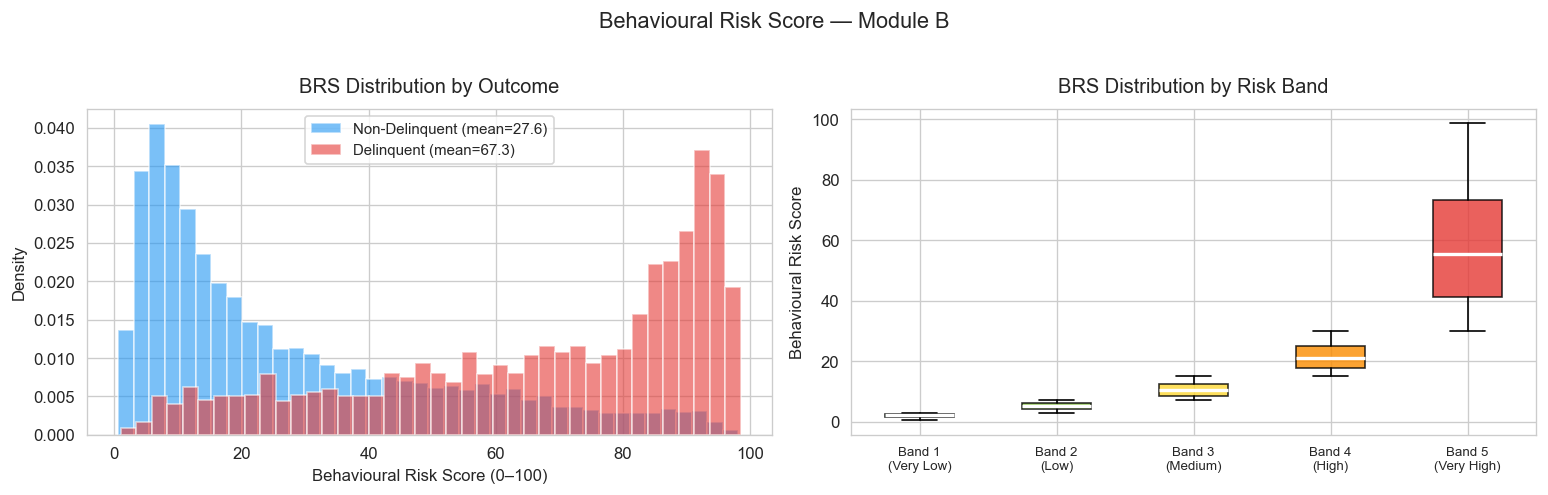

In [19]:
brs = (xgb_pd_test * 100).round(1)

print("BEHAVIOURAL RISK SCORE DISTRIBUTION")
print("=" * 50)
print(f"Mean BRS  : {brs.mean():.1f}")
print(f"Median BRS: {np.median(brs):.1f}")
print(f"90th pct  : {np.percentile(brs, 90):.1f}")
print(f"99th pct  : {np.percentile(brs, 99):.1f}")
print(f"Max BRS   : {brs.max():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(brs[y_test==0], bins=40, alpha=0.6, color="#2196F3",
             label=f"Non-Delinquent (mean={brs[y_test==0].mean():.1f})", density=True)
axes[0].hist(brs[y_test==1], bins=40, alpha=0.6, color="#E53935",
             label=f"Delinquent (mean={brs[y_test==1].mean():.1f})",     density=True)
axes[0].set_title("BRS Distribution by Outcome", fontsize=12, pad=10)
axes[0].set_xlabel("Behavioural Risk Score (0–100)")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=9)

# Box plots by band
brs_by_band = [brs[risk_bands_b==i] for i in range(1,6)]
bp = axes[1].boxplot(brs_by_band, patch_artist=True,
                     medianprops=dict(color="white", linewidth=2))
for patch, color in zip(bp["boxes"], band_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[1].set_xticks(range(1,6))
axes[1].set_xticklabels(band_labels, fontsize=8)
axes[1].set_title("BRS Distribution by Risk Band", fontsize=12, pad=10)
axes[1].set_ylabel("Behavioural Risk Score")

plt.suptitle("Behavioural Risk Score — Module B", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---
## 9. PSI — Score Stability Check

Population Stability Index monitors whether the score distribution has shifted between training and test sets. Same methodology as Module A.

PSI — Logistic Regression : 0.0006  STABLE ✓
PSI — XGBoost             : 0.0007  STABLE ✓

Thresholds: < 0.10 = stable | 0.10–0.25 = monitor | > 0.25 = recalibrate


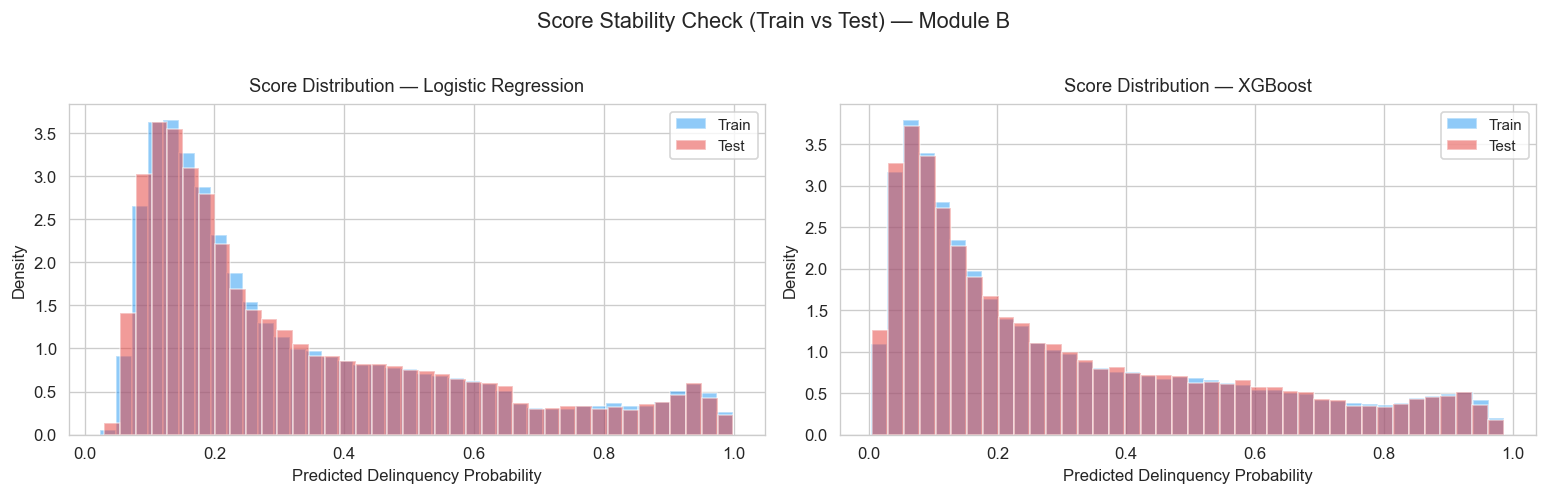

In [20]:
def calculate_psi(expected, actual, bins=10):
    """PSI between train and test score distributions."""
    breakpoints   = np.linspace(0, 1, bins+1)
    expected_pct  = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_pct    = np.histogram(actual,   bins=breakpoints)[0] / len(actual)
    expected_pct  = np.where(expected_pct == 0, 0.0001, expected_pct)
    actual_pct    = np.where(actual_pct   == 0, 0.0001, actual_pct)
    return ((actual_pct - expected_pct) * np.log(actual_pct / expected_pct)).sum()

psi_lr  = calculate_psi(lr_pd_train,  lr_pd_test)
psi_xgb = calculate_psi(xgb_pd_train, xgb_pd_test)

def psi_status(v):
    if v < 0.10: return "STABLE ✓"
    if v < 0.25: return "MONITOR ⚠"
    return "UNSTABLE ✗"

print(f"PSI — Logistic Regression : {psi_lr:.4f}  {psi_status(psi_lr)}")
print(f"PSI — XGBoost             : {psi_xgb:.4f}  {psi_status(psi_xgb)}")
print(f"\nThresholds: < 0.10 = stable | 0.10–0.25 = monitor | > 0.25 = recalibrate")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, pd_train, pd_test, name in zip(
        axes, [lr_pd_train, xgb_pd_train], [lr_pd_test, xgb_pd_test],
        ["Logistic Regression", "XGBoost"]):
    ax.hist(pd_train, bins=40, alpha=0.5, color="#2196F3", label="Train", density=True)
    ax.hist(pd_test,  bins=40, alpha=0.5, color="#E53935", label="Test",  density=True)
    ax.set_title(f"Score Distribution — {name}", fontsize=11, pad=8)
    ax.set_xlabel("Predicted Delinquency Probability")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)
plt.suptitle("Score Stability Check (Train vs Test) — Module B", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---
## 10. Save Scored Dataset and Models

In [22]:
# ── Build scored output ───────────────────────────────────────────────────────
scored_b = X_test.copy().reset_index(drop=True)
scored_b["ACTUAL_DELINQUENCY"]    = y_test.values
scored_b["DELINQUENCY_PROB_LR"]   = lr_pd_test
scored_b["DELINQUENCY_PROB_XGB"]  = xgb_pd_test
scored_b["DELINQUENCY_PROB"]      = xgb_pd_test          # champion model
scored_b["BEHAVIOURAL_RISK_BAND"] = risk_bands_b.values
scored_b["BEHAVIOURAL_RISK_SCORE"]= brs

# ── Derive utilisation risk label ─────────────────────────────────────────────
def util_label(band):
    return {0:"Low", 1:"Low", 2:"Medium", 3:"High", 4:"Critical"}.get(int(band), "Medium")

if "UTILIZATION_RISK_BAND" in scored_b.columns:
    scored_b["UTILISATION_RISK"] = scored_b["UTILIZATION_RISK_BAND"].apply(util_label)

# ── Stress flag ───────────────────────────────────────────────────────────────
if "HAS_90DAY_LATE" in scored_b.columns and "DELINQUENCY_SCORE" in scored_b.columns:
    scored_b["STRESS_FLAG"] = (
        (scored_b["HAS_90DAY_LATE"] == 1) |
        (scored_b["DELINQUENCY_SCORE"] >= 3)
    ).astype(int)

scored_b.to_csv("../01_data/processed/scored_test_b.csv", index=False)
print(f"Scored dataset saved: {scored_b.shape[0]:,} rows")
print(f"Output columns: {list(scored_b.columns[-8:])}")

# ── Save models ───────────────────────────────────────────────────────────────
with open("../03_models/lr_behavioural.pkl", "wb") as f:
    pickle.dump({"model": lr_model, "scaler": scaler}, f)

with open("../03_models/xgb_behavioural.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

print("\nModels saved to ../03_models/")
print("  lr_behavioural.pkl  (model + scaler)")
print("  xgb_behavioural.pkl")


Scored dataset saved: 29,946 rows
Output columns: ['ACTUAL_DELINQUENCY', 'DELINQUENCY_PROB_LR', 'DELINQUENCY_PROB_XGB', 'DELINQUENCY_PROB', 'BEHAVIOURAL_RISK_BAND', 'BEHAVIOURAL_RISK_SCORE', 'UTILISATION_RISK', 'STRESS_FLAG']

Models saved to ../03_models/
  lr_behavioural.pkl  (model + scaler)
  xgb_behavioural.pkl


---
## 11. Module B Signal Summary

### Model Performance Summary

| Model | Role | AUC | KS | Gini |
|-------|------|-----|-----|------|
| Logistic Regression | Challenger | *see output* | *see output* | *see output* |
| XGBoost | Champion | *see output* | *see output* | *see output* |

### Signal Output Schema

```python
# Module B signal output — feeds into Decision Engine
{
  "delinquency_prob":       float,  # 0.0–1.0  P(90-day delinquency in 2 years)
  "behavioural_risk_score": float,  # 0–100    scaled from delinquency_prob
  "behavioural_risk_band":  int,    # 1–5      (1=Very Low, 5=Very High)
  "utilisation_risk":       str,    # "Low" / "Medium" / "High" / "Critical"
  "stress_flag":            bool,   # True if delinquency score ≥ 3 or has 90DPD history
}
```

### Cross-Module Coherence Check

The behavioural signal (Module B) is **complementary, not redundant** to the application signal (Module A):

| Module A PD | Module B Delinquency Prob | Interpretation |
|-------------|--------------------------|----------------|
| Low (< 10%) | Low (< 7%) | Both signals agree: approve with confidence |
| Low (< 10%) | High (> 15%) | Warning: borrower deteriorating post-application. Manual review |
| High (> 20%) | Low (< 7%) | Possible: low-income applicant with perfect payment record. Consider approve at higher rate |
| High (> 20%) | High (> 15%) | Both signals agree: decline |

This is precisely the decision logic the Decision Engine (Module D) will formalise.

### Next Step

`scored_test_b.csv` feeds into `03_behavioural_scorecard.ipynb` where a WoE-based behavioural scorecard is constructed — mirroring the scorecard methodology in Module A for cross-module interpretability.
